# Manual Implementation of scVI

This notebook replicates the VAE in the **scVI** library for single‑cell transcriptomics.

We will:
1. Load a toy heart atlas dataset (scvi‑tools).
2. Train a standard continuous‑latent scVI model.
3. Manually implement continuous scVI model
4. Compare latent spaces, reconstruction quality, and verify the correctness of the manual implementation for the next step (add discretization to z).

In [ ]:
# Install required packages (run once)
!pip install --quiet scvi-tools scanpy matplotlib umap-learn

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.8 MB/s eta 0:00:00
 

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, Bernoulli

import scvi
from scvi import REGISTRY_KEYS
from scvi.module import VAE
from scvi.model.base import (
    BaseModelClass,
    VAEMixin,
    RNASeqMixin,
    ArchesMixin,
    UnsupervisedTrainingMixin,
    BaseMinifiedModeModelClass,
)
from scvi.train import TrainRunner
from scvi.data import AnnDataManager
from scvi.data.fields import (
    LayerField,
    NumericalObsField,
    CategoricalObsField,
)

import matplotlib.pyplot as plt
import umap

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/scvi_data'
os.makedirs(save_dir, exist_ok=True)

Mounted at /content/drive


## 1. Load and Prepare Toy Dataset

In [ ]:
# Load heart cell atlas subsampled
adata = scvi.data.heart_cell_atlas_subsampled()
print(adata)

INFO     File data/hca_subsampled_20k.h5ad already downloaded                                                      
AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'


In [ ]:
# Basic filtering and HVG selection
sc.pp.filter_genes(adata, min_counts=3) # Minimum gene expressed in 3 cells
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable].copy()
adata.shape

(18641, 2000)

## 2. Baseline (call scVI)

In [ ]:
from pathlib import Path

my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_cont")
if my_file.exists():
    cont_model = scvi.model.SCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for standard SCVI
    scvi.model.SCVI.setup_anndata(adata, layer="counts")
    cont_model = scvi.model.SCVI(adata, n_latent=10, n_hidden=128, n_layers=2)

INFO     File /content/drive/MyDrive/scvi_data/scvi_model_cont/model.pt already downloaded                         


In [ ]:
# Train
if not my_file.exists():
    cont_model.train(max_epochs=200, early_stopping=True, plan_kwargs={"lr": 1e-3})

In [ ]:
# Save model
if not my_file.exists():
    model_dir = os.path.join(save_dir, "scvi_model_cont")
    cont_model.save(model_dir, overwrite=True)

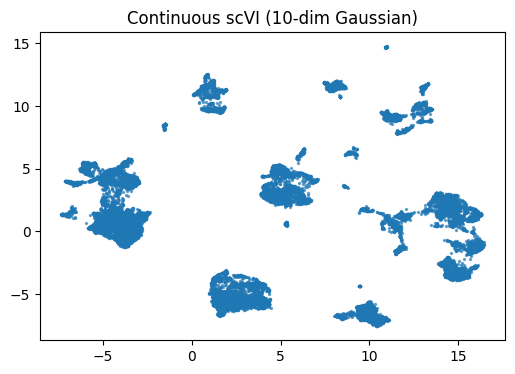

In [ ]:
# Extract latent representation and compute UMAP
cont_latent = cont_model.get_latent_representation()
cont_umap = umap.UMAP().fit_transform(cont_latent)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(cont_umap[:,0], cont_umap[:,1], s=2, alpha=0.6)
ax.set_title("Continuous scVI (10-dim Gaussian)")
plt.show()

In [ ]:
print(cont_latent.shape)

(18641, 10)


## 3. BaselineSCVI - Manual

In [ ]:
from __future__ import annotations

import logging
import warnings
from typing import Literal, Optional, Union, Sequence

import numpy as np
from anndata import AnnData

from scvi import REGISTRY_KEYS, settings
from scvi._types import MinifiedDataType
from scvi.data import AnnDataManager
from scvi.data._constants import _ADATA_MINIFY_TYPE_UNS_KEY, ADATA_MINIFY_TYPE
from scvi.data._utils import _get_adata_minify_type
from scvi.data.fields import (
    BaseAnnDataField,
    CategoricalJointObsField,
    CategoricalObsField,
    LayerField,
    NumericalJointObsField,
    NumericalObsField,
    ObsmField,
    StringUnsField,
)
from scvi.model._utils import _init_library_size
from scvi.model.base import UnsupervisedTrainingMixin
from scvi.model.utils import get_minified_adata_scrna
from scvi.module import VAE
from scvi.utils import setup_anndata_dsp

from scvi.dataloaders import DataSplitter
from scvi.train import TrainingPlan, TrainRunner
from scvi.model._utils import get_max_epochs_heuristic

In [ ]:
class BaselineSCVI(RNASeqMixin, VAEMixin, ArchesMixin, UnsupervisedTrainingMixin, BaseMinifiedModeModelClass):
    """single-cell Variational Inference :cite:p:`Lopez18`.

    Parameters
    ----------
    adata: AnnData object that has been registered via `~scvi.model.SCVI.setup_anndata`.
    n_hidden: Number of nodes per hidden layer.
    n_latent: Dimensionality of the latent space.
    n_layers: Number of hidden layers used for encoder and decoder NNs.
    dropout_rate: Dropout rate for neural networks.
    dispersion
        * ``'gene'`` - dispersion parameter of NB is constant per gene across cells
        * ``'gene-batch'`` - dispersion can differ between different batches
        * ``'gene-label'`` - dispersion can differ between different labels
        * ``'gene-cell'`` - dispersion can differ for every gene in every cell
    gene_likelihood
        * ``'nb'`` - Negative binomial distribution
        * ``'zinb'`` - Zero-inflated negative binomial distribution
        * ``'poisson'`` - Poisson distribution
    latent_distribution
        * ``'normal'`` - Normal distribution
        * ``'ln'`` - Logistic normal distribution (Normal(0, I) transformed by softmax)
    **kwargs: Additional keyword arguments for :class:`~scvi.module.VAE`.
    """


    _module_cls = VAE


    def __init__(
        self,
        adata,
        n_hidden: int = 128,
        n_latent: int = 10,
        n_layers: int = 1,
        dropout_rate: float = 0.1,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln"] = "normal",
        **kwargs,
    ):
        super().__init__(adata)


        self._module_kwargs = {
            "n_hidden": n_hidden,
            "n_latent": n_latent,
            "n_layers": n_layers,
            "dropout_rate": dropout_rate,
            "dispersion": dispersion,
            "gene_likelihood": gene_likelihood,
            "latent_distribution": latent_distribution,
            **kwargs,
        }
        self._model_summary_string = (
            "SCVI model with the following parameters: \n"
            f"n_hidden: {n_hidden}, n_latent: {n_latent}, n_layers: {n_layers}, "
            f"dropout_rate: {dropout_rate}, dispersion: {dispersion}, "
            f"gene_likelihood: {gene_likelihood}, latent_distribution: {latent_distribution}."
        )


        if self._module_init_on_train:
            self.module = None
            warnings.warn(
                "Model was initialized without `adata`. The module will be initialized when "
                "calling `train`. This behavior is experimental and may change in the future.",
                UserWarning,
                stacklevel=settings.warnings_stacklevel,
            )
        else:
            n_cats_per_cov = (
                self.adata_manager.get_state_registry(REGISTRY_KEYS.CAT_COVS_KEY).n_cats_per_key
                if REGISTRY_KEYS.CAT_COVS_KEY in self.adata_manager.data_registry
                else None
            )
            n_batch = self.summary_stats.n_batch
            use_size_factor_key = REGISTRY_KEYS.SIZE_FACTOR_KEY in self.adata_manager.data_registry
            library_log_means, library_log_vars = None, None
            if not use_size_factor_key and self.minified_data_type is None:
                library_log_means, library_log_vars = _init_library_size(
                    self.adata_manager, n_batch
                )
            self.module = self._module_cls(
                n_input=self.summary_stats.n_vars,
                n_batch=n_batch,
                n_labels=self.summary_stats.n_labels,
                n_continuous_cov=self.summary_stats.get("n_extra_continuous_covs", 0),
                n_cats_per_cov=n_cats_per_cov,
                n_hidden=n_hidden,
                n_latent=n_latent,
                n_layers=n_layers,
                dropout_rate=dropout_rate,
                dispersion=dispersion,
                gene_likelihood=gene_likelihood,
                latent_distribution=latent_distribution,
                use_size_factor_key=use_size_factor_key,
                library_log_means=library_log_means,
                library_log_vars=library_log_vars,
                **kwargs,
            )


        self.init_params_ = self._get_init_params(locals())


    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        layer: str | None = None,
        batch_key: str | None = None,
        labels_key: str | None = None,
        size_factor_key: str | None = None,
        categorical_covariate_keys: list[str] | None = None,
        continuous_covariate_keys: list[str] | None = None,
        **kwargs,
    ):
        """%(summary)s.

        Parameters
        ----------
        %(param_adata)s
        %(param_layer)s
        %(param_batch_key)s
        %(param_labels_key)s
        %(param_size_factor_key)s
        %(param_cat_cov_keys)s
        %(param_cont_cov_keys)s
        """
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=True),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            CategoricalObsField(REGISTRY_KEYS.LABELS_KEY, labels_key),
            NumericalObsField(REGISTRY_KEYS.SIZE_FACTOR_KEY, size_factor_key, required=False),
            CategoricalJointObsField(REGISTRY_KEYS.CAT_COVS_KEY, categorical_covariate_keys),
            NumericalJointObsField(REGISTRY_KEYS.CONT_COVS_KEY, continuous_covariate_keys),
        ]
        # register new fields if the adata is minified
        adata_minify_type = _get_adata_minify_type(adata)
        if adata_minify_type is not None:
            anndata_fields += cls._get_fields_for_adata_minification(adata_minify_type)
        adata_manager = AnnDataManager(fields=anndata_fields, setup_method_args=setup_method_args)
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)


    @torch.inference_mode()
    def get_latent_representation(
        self,
        adata: Optional[AnnData] = None,
        indices: Optional[Sequence[int]] = None,
        give_mean: bool = True,
        mc_samples: int = 5000,
        batch_size: Optional[int] = None,
        return_dist: bool = False,
    ) -> Union[np.ndarray, tuple[np.ndarray, np.ndarray]]:
        """Return the latent representation for each cell.

        This is typically denoted as :math:`z_n`.

        Parameters
        ----------
        adata
            AnnData object with equivalent structure to initial AnnData. If `None`, defaults to the
            AnnData object used to initialize the model.
        indices
            Indices of cells in adata to use. If `None`, all cells are used.
        give_mean
            Give mean of distribution or sample from it.
        mc_samples
            For distributions with no closed-form mean (e.g., `logistic normal`), how many Monte Carlo
            samples to take for computing mean.
        batch_size
            Minibatch size for data loading into model. Defaults to `scvi.settings.batch_size`.
        return_dist
            Return (mean, variance) of distributions instead of just the mean.
            If `True`, ignores `give_mean` and `mc_samples`. In the case of the latter,
            `mc_samples` is used to compute the mean of a transformed distribution.
            If `return_dist` is true the untransformed mean and variance are returned.

        Returns
        -------
        Low-dimensional representation for each cell or a tuple containing its mean and variance.
        """
        self._check_if_trained(warn=False)


        adata = self._validate_anndata(adata)
        scdl = self._make_data_loader(adata=adata, indices=indices, batch_size=batch_size)
        latent = []
        latent_qzm = []
        latent_qzv = []
        for tensors in scdl:
            inference_inputs = self.module._get_inference_input(tensors)
            outputs = self.module.inference(**inference_inputs)
            if "qz" in outputs:
                qz = outputs["qz"]
            else:
                qz_m, qz_v = outputs["qz_m"], outputs["qz_v"]
                qz = torch.distributions.Normal(qz_m, qz_v.sqrt())
            if give_mean:
                # does each model need to have this latent distribution param?
                if self.module.latent_distribution == "ln":
                    samples = qz.sample([mc_samples])
                    z = torch.nn.functional.softmax(samples, dim=-1)
                    z = z.mean(dim=0)
                else:
                    z = qz.loc
            else:
                z = outputs["z"]


            latent += [z.cpu()]
            latent_qzm += [qz.loc.cpu()]
            latent_qzv += [qz.scale.square().cpu()]
        return (
            (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
            if return_dist
            else torch.cat(latent).numpy()
        )


    def train(
        self,
        max_epochs: int | None = None,
        accelerator: str = "auto",
        devices: int | list[int] | str = "auto",
        train_size: float = 0.9,
        validation_size: float | None = None,
        shuffle_set_split: bool = True,
        batch_size: int = 128,
        early_stopping: bool = False,
        plan_kwargs: dict | None = None,
        **trainer_kwargs,
    ):
        """
        Train the model.

        Parameters
        ----------
        max_epochs : int, optional
            Maximum number of epochs. If None, a heuristic based on dataset size is used.
        accelerator : str
            "cpu", "gpu", "tpu", etc.
        devices : int, list, or str
            Number of devices or device indices.
        train_size : float
            Fraction of data used for training (0.0 - 1.0).
        validation_size : float, optional
            Fraction of data used for validation. If None, uses 1 - train_size.
        shuffle_set_split : bool
            Whether to shuffle data before splitting.
        batch_size : int
            Minibatch size.
        early_stopping : bool
            If True, stops training when validation loss stops improving.
        plan_kwargs : dict, optional
            Extra arguments passed to the TrainingPlan (e.g., learning rate).
        **trainer_kwargs
            Additional arguments for the PyTorch Lightning Trainer.
        """
        # ----- 1. Determine max_epochs if not provided -----
        if max_epochs is None:
            max_epochs = get_max_epochs_heuristic(self.adata.n_obs)

        # ----- 2. Create the data splitter -----
        data_module = DataSplitter(
            self.adata_manager,
            train_size=train_size,
            validation_size=validation_size,
            batch_size=batch_size,
            shuffle_set_split=shuffle_set_split,
        )

        # ----- 3. Create the training plan -----
        plan_kwargs = plan_kwargs or {}
        training_plan = TrainingPlan(self.module, **plan_kwargs)

        # ----- 4. Ensure early_stopping is passed correctly -----
        if "early_stopping" not in trainer_kwargs:
            trainer_kwargs["early_stopping"] = early_stopping

        # ----- 5. Create the runner and run training -----
        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_module,
            max_epochs=max_epochs,
            accelerator=accelerator,
            devices=devices,
            **trainer_kwargs,
        )
        runner()   # This calls Trainer.fit() and sets self.is_trained_ = True

### Train

In [ ]:
from pathlib import Path

my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_baseline")
if my_file.exists():
    baseline_model = scvi.model.SCVI.load(my_file, adata=adata)
else:
    BaselineSCVI.setup_anndata(adata, layer="counts")
    baseline_model = BaselineSCVI(adata, n_latent=10, n_hidden=128, n_layers=2)
    baseline_model.train(max_epochs=200, early_stopping=True, plan_kwargs={"lr": 1e-3})
    model_dir = os.path.join(save_dir, "scvi_model_baseline")
    baseline_model.save(model_dir, overwrite=True)

In [ ]:
baseline_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

In [ ]:
# baseline_model.train(max_epochs=200, early_stopping=True, plan_kwargs={"lr": 1e-3})

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


In [ ]:
# Extract latent representation and compute UMAP
baseline_latent = baseline_model.get_latent_representation()
baseline_umap = umap.UMAP().fit_transform(baseline_latent)

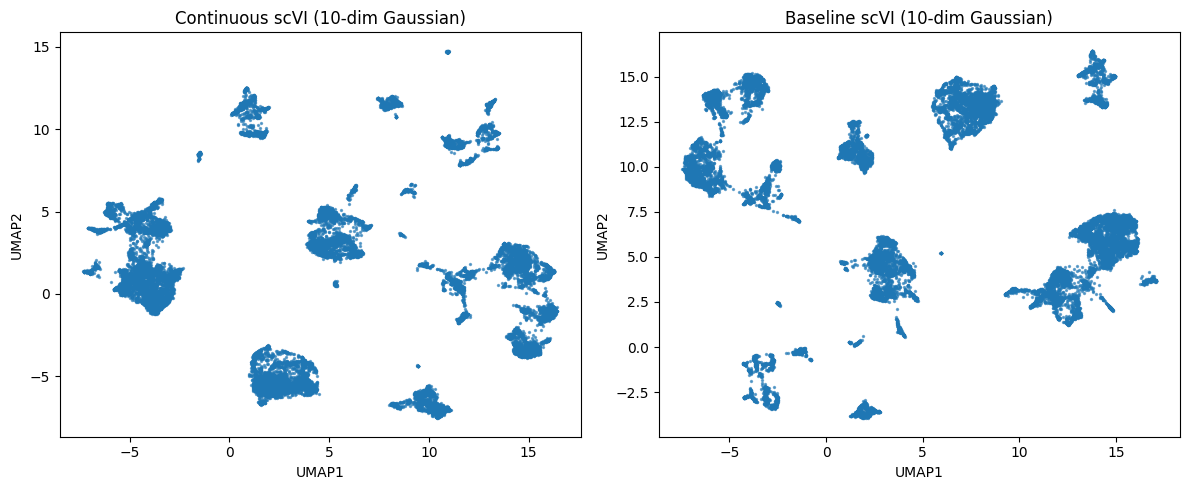

In [ ]:
# Check that the custom implementation provides the same results
# Plot UMAP visualization side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(cont_umap[:,0], cont_umap[:,1], s=2, alpha=0.6)
axes[0].set_title("Continuous scVI (10-dim Gaussian)")
axes[1].scatter(baseline_umap[:,0], baseline_umap[:,1], s=2, alpha=0.6)
axes[1].set_title("Baseline scVI (10-dim Gaussian)")
for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.show()

In [ ]:
# Results are very different, let's investigate

from scvi import REGISTRY_KEYS
import torch
import numpy as np

def compute_library_manual(module, x, batch_index):
    library = torch.log(x.sum(dim=1, keepdim=True))
    if hasattr(module, 'library_log_means') and module.library_log_means is not None:
        library = (library - module.library_log_means[batch_index]) / torch.sqrt(
            module.library_log_vars[batch_index]
        )
    return library

cont_model.module.eval()
baseline_model.module.eval()

# Use the model's own AnnData to guarantee the manager is found
test_loader_cont = cont_model._make_data_loader(
    adata=cont_model.adata, batch_size=128
)
test_loader_baseline = baseline_model._make_data_loader(
    adata=baseline_model.adata, batch_size=128
)

batch_cont = next(iter(test_loader_cont))
batch_baseline = next(iter(test_loader_baseline))

with torch.no_grad():
    # Continuous model
    x_cont = batch_cont[REGISTRY_KEYS.X_KEY]
    batch_idx_cont = batch_cont[REGISTRY_KEYS.BATCH_KEY]

    inf_cont = cont_model.module.inference(x=x_cont, batch_index=batch_idx_cont)
    library_cont = compute_library_manual(cont_model.module, x_cont, batch_idx_cont)
    gen_cont = cont_model.module.generative(inf_cont["z"], library=library_cont, batch_index=batch_idx_cont)
    loss_output_cont = cont_model.module.loss(batch_cont, inf_cont, gen_cont)
    elbo_cont = loss_output_cont.loss.item()

    # Baseline model
    x_baseline = batch_baseline[REGISTRY_KEYS.X_KEY]
    batch_idx_baseline = batch_baseline[REGISTRY_KEYS.BATCH_KEY]

    inf_baseline = baseline_model.module.inference(x=x_baseline, batch_index=batch_idx_baseline)
    library_baseline = compute_library_manual(baseline_model.module, x_baseline, batch_idx_baseline)
    gen_baseline = baseline_model.module.generative(inf_baseline["z"], library=library_baseline, batch_index=batch_idx_baseline)
    loss_output_baseline = baseline_model.module.loss(batch_baseline, inf_baseline, gen_baseline)
    elbo_baseline = loss_output_baseline.loss.item()


### Understanding ELBO = Reconstruction loss - KL Divergence

Reconstruction loss is the per‑cell negative log‑likelihood values.

`reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)`

- `[MODULE_KEYS.PX_KEY]`: distribution object (e.g., ZINB) for the counts
-  `.log_prob(x)`: log-probability of the observed counts x under distribution, per gene, per cell. output (batch_size, n_genes)
- `.sum(-1)`: sum per gene. log-likelihood per cell. output(batch_size)
- `-`: negative log-likelihood (loss)

KL Divergence is the difference between inference and generative values.
[(Function)](https://docs.pytorch.org/docs/2.12/distributions.html#torch.distributions.kl.kl_divergence)

`weighted_kl_local = kl_weight * kl_local_for_warmup + kl_local_no_warmup`

- `kl_weight` defautl value of 1
- `kl_local_for_warmup`: `kl_divergence(inference_outputs[MODULE_KEYS.QZ_KEY], generative_outputs[MODULE_KEYS.PZ_KEY]).sum(dim=-1)`
- if `not self._use_observed_lib_size`: `kl_local_no_warmup`: `kl_divergence(inference_outputs[MODULE_KEYS.QL_KEY], generative_outputs[MODULE_KEYS.PL_KEY]).sum(dim=-1)`

ELBO: `loss = torch.mean(reconst_loss + weighted_kl_local)`

In [ ]:
loss_output_cont.reconstruction_loss['reconstruction_loss'].size()

torch.Size([128])

In [ ]:
loss_output_cont.kl_local['kl_divergence_z'].size()

torch.Size([128])

In [ ]:
gen_cont['px'].mean.size() # 128, 2000

torch.Size([128, 2000])

In [ ]:
# Checks

# lib_internal = cont_model.module._compute_library(x_cont, batch_idx_cont)
# assert torch.allclose(library_cont, lib_internal), "Library mismatch"
# print("✓ Manual library matches internal `_compute_library`.")

print(f"Continuous scVI ELBO: {elbo_cont:.4f}")
print(f"Baseline scVI ELBO  : {elbo_baseline:.4f}")
# assert np.isclose(elbo_cont, elbo_baseline, atol=1e-3), "ELBOs differ significantly!"
# print("✓ ELBOs are consistent.")

px_rate_cont = gen_cont['px'].mean
px_rate_baseline = gen_baseline['px'].mean
mae_px_rate = torch.mean(torch.abs(px_rate_cont - px_rate_baseline)).item()
print(f"Mean Absolute Error (px_rate): {mae_px_rate:.4e}")
# assert mae_px_rate < 1e-4, "Reconstructed gene expressions differ significantly!"
# print("✓ Reconstructed gene expressions (px_rate) are consistent.")

Continuous scVI ELBO: 463.5160
Baseline scVI ELBO  : 468.3804
Mean Absolute Error (px_rate): 5.4549e-02




> What needs to happen to emulate coded dVAE?
> 1. Implement Coded mechanism with ECC and matrices G and H
> 2.  Reparametrization trick to generate discrete latent space $z$



### Evaluate

In [ ]:
import torch
import numpy as np
import random
from scvi.model import SCVI
from scvi.model._utils import get_max_epochs_heuristic

# 1. Fix all seeds
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# 2. Force deterministic backend (optional, may slow down GPU)
# torch.use_deterministic_algorithms(True)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# 3. Define training parameters – must be identical
n_latent = 10
n_hidden = 128
n_layers = 2
batch_size = 128
max_epochs = 200
lr = 1e-3
early_stopping = True
train_size = 0.9
shuffle_set_split = True   # but with fixed seed it will split the same way

In [ ]:
# ---------------------------------------------------------------------
# Official model (scvi-tools)
# ---------------------------------------------------------------------
# Re‑setup the AnnData to guarantee a clean state
SCVI.setup_anndata(adata, layer="counts")
official_model = SCVI(adata,
                      n_latent=n_latent,
                      n_hidden=n_hidden,
                      n_layers=n_layers,
                      dispersion="gene",
                      gene_likelihood="zinb",
                      latent_distribution="normal")

official_model.train(max_epochs=max_epochs,
                    early_stopping=early_stopping,
                    train_size=train_size,
                    shuffle_set_split=shuffle_set_split,
                    batch_size=batch_size,
                    plan_kwargs={"lr": lr})
model_dir = os.path.join(save_dir, "scvi_model_test_official")
official_model.save(model_dir, overwrite=True)

In [ ]:
# ---------------------------------------------------------------------
# Custom model (BaselineSCVI) – reset seeds to get same initialisation
# ---------------------------------------------------------------------
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Re‑setup
BaselineSCVI.setup_anndata(adata, layer="counts")
custom_model = BaselineSCVI(adata,
                            n_latent=n_latent,
                            n_hidden=n_hidden,
                            n_layers=n_layers,
                            dispersion="gene",
                            gene_likelihood="zinb",
                            latent_distribution="normal")
custom_model.train(max_epochs=max_epochs,
                   early_stopping=early_stopping,
                   train_size=train_size,
                   shuffle_set_split=shuffle_set_split,
                   batch_size=batch_size,
                   plan_kwargs={"lr": lr})
model_dir = os.path.join(save_dir, "scvi_model_test_custom")
custom_model.save(model_dir, overwrite=True)

In [ ]:
official_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

In [ ]:
# Compare
# Results are very different, let's investigate

from scvi import REGISTRY_KEYS
import torch
import numpy as np

def compute_library_manual(module, x, batch_index):
    library = torch.log(x.sum(dim=1, keepdim=True))
    if hasattr(module, 'library_log_means') and module.library_log_means is not None:
        library = (library - module.library_log_means[batch_index]) / torch.sqrt(
            module.library_log_vars[batch_index]
        )
    return library

official_model.module.eval()
custom_model.module.eval()

# Use the model's own AnnData to guarantee the manager is found
test_loader_cont = official_model._make_data_loader(
    adata=official_model.adata, batch_size=128
)
test_loader_baseline = custom_model._make_data_loader(
    adata=custom_model.adata, batch_size=128
)

batch_cont = next(iter(test_loader_cont))
batch_baseline = next(iter(test_loader_baseline))

with torch.no_grad():
    # Continuous model
    x_cont = batch_cont[REGISTRY_KEYS.X_KEY]
    batch_idx_cont = batch_cont[REGISTRY_KEYS.BATCH_KEY]

    inf_cont = official_model.module.inference(x=x_cont, batch_index=batch_idx_cont)
    library_cont = compute_library_manual(official_model.module, x_cont, batch_idx_cont)
    gen_cont = official_model.module.generative(inf_cont["z"], library=library_cont, batch_index=batch_idx_cont)
    loss_output_cont = official_model.module.loss(batch_cont, inf_cont, gen_cont)
    elbo_cont = loss_output_cont.loss.item()

    # Baseline model
    x_baseline = batch_baseline[REGISTRY_KEYS.X_KEY]
    batch_idx_baseline = batch_baseline[REGISTRY_KEYS.BATCH_KEY]

    inf_baseline = custom_model.module.inference(x=x_baseline, batch_index=batch_idx_baseline)
    library_baseline = compute_library_manual(custom_model.module, x_baseline, batch_idx_baseline)
    gen_baseline = custom_model.module.generative(inf_baseline["z"], library=library_baseline, batch_index=batch_idx_baseline)
    loss_output_baseline = custom_model.module.loss(batch_baseline, inf_baseline, gen_baseline)
    elbo_baseline = loss_output_baseline.loss.item()


In [ ]:
print(f"Continuous scVI ELBO: {elbo_cont:.4f}")
print(f"Baseline scVI ELBO  : {elbo_baseline:.4f}")
# assert np.isclose(elbo_cont, elbo_baseline, atol=1e-3), "ELBOs differ significantly!"
# print("✓ ELBOs are consistent.")

px_rate_cont = gen_cont['px'].mean
px_rate_baseline = gen_baseline['px'].mean
mae_px_rate = torch.mean(torch.abs(px_rate_cont - px_rate_baseline)).item()
print(f"Mean Absolute Error (px_rate): {mae_px_rate:.4e}")
# assert mae_px_rate < 1e-4, "Reconstructed gene expressions differ significantly!"
# print("✓ Reconstructed gene expressions (px_rate) are consistent.")

Continuous scVI ELBO: 464.8575
Baseline scVI ELBO  : 465.3741
Mean Absolute Error (px_rate): 5.9516e-02


## 4. FullBaselineSCVI + VAEModule

In [ ]:
class FullBaselineSCVI(RNASeqMixin, VAEMixin, ArchesMixin, UnsupervisedTrainingMixin, BaseMinifiedModeModelClass):
    """single-cell Variational Inference :cite:p:`Lopez18`.

    Parameters
    ----------
    adata: AnnData object that has been registered via `~scvi.model.SCVI.setup_anndata`.
    n_hidden: Number of nodes per hidden layer.
    n_latent: Dimensionality of the latent space.
    n_layers: Number of hidden layers used for encoder and decoder NNs.
    dropout_rate: Dropout rate for neural networks.
    dispersion
        * ``'gene'`` - dispersion parameter of NB is constant per gene across cells
        * ``'gene-batch'`` - dispersion can differ between different batches
        * ``'gene-label'`` - dispersion can differ between different labels
        * ``'gene-cell'`` - dispersion can differ for every gene in every cell
    gene_likelihood
        * ``'nb'`` - Negative binomial distribution
        * ``'zinb'`` - Zero-inflated negative binomial distribution
        * ``'poisson'`` - Poisson distribution
    latent_distribution
        * ``'normal'`` - Normal distribution
        * ``'ln'`` - Logistic normal distribution (Normal(0, I) transformed by softmax)
    **kwargs: Additional keyword arguments for :class:`~scvi.module.VAE`.
    """


    _module_cls = VAEModule


    def __init__(
        self,
        adata,
        n_hidden: int = 128,
        n_latent: int = 10,
        n_layers: int = 1,
        dropout_rate: float = 0.1,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln"] = "normal",
        **kwargs,
    ):
        super().__init__(adata)


        self._module_kwargs = {
            "n_hidden": n_hidden,
            "n_latent": n_latent,
            "n_layers": n_layers,
            "dropout_rate": dropout_rate,
            "dispersion": dispersion,
            "gene_likelihood": gene_likelihood,
            "latent_distribution": latent_distribution,
            **kwargs,
        }
        self._model_summary_string = (
            "SCVI model with the following parameters: \n"
            f"n_hidden: {n_hidden}, n_latent: {n_latent}, n_layers: {n_layers}, "
            f"dropout_rate: {dropout_rate}, dispersion: {dispersion}, "
            f"gene_likelihood: {gene_likelihood}, latent_distribution: {latent_distribution}."
        )


        if self._module_init_on_train:
            self.module = None
            warnings.warn(
                "Model was initialized without `adata`. The module will be initialized when "
                "calling `train`. This behavior is experimental and may change in the future.",
                UserWarning,
                stacklevel=settings.warnings_stacklevel,
            )
        else:
            n_cats_per_cov = (
                self.adata_manager.get_state_registry(REGISTRY_KEYS.CAT_COVS_KEY).n_cats_per_key
                if REGISTRY_KEYS.CAT_COVS_KEY in self.adata_manager.data_registry
                else None
            )
            n_batch = self.summary_stats.n_batch
            use_size_factor_key = REGISTRY_KEYS.SIZE_FACTOR_KEY in self.adata_manager.data_registry
            library_log_means, library_log_vars = None, None
            if not use_size_factor_key and self.minified_data_type is None:
                library_log_means, library_log_vars = _init_library_size(
                    self.adata_manager, n_batch
                )
            self.module = self._module_cls(
                n_input=self.summary_stats.n_vars,
                n_batch=n_batch,
                n_labels=self.summary_stats.n_labels,
                n_continuous_cov=self.summary_stats.get("n_extra_continuous_covs", 0),
                n_cats_per_cov=n_cats_per_cov,
                n_hidden=n_hidden,
                n_latent=n_latent,
                n_layers=n_layers,
                dropout_rate=dropout_rate,
                dispersion=dispersion,
                gene_likelihood=gene_likelihood,
                latent_distribution=latent_distribution,
                use_size_factor_key=use_size_factor_key,
                library_log_means=library_log_means,
                library_log_vars=library_log_vars,
                **kwargs,
            )


        self.init_params_ = self._get_init_params(locals())


    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        layer: str | None = None,
        batch_key: str | None = None,
        labels_key: str | None = None,
        size_factor_key: str | None = None,
        categorical_covariate_keys: list[str] | None = None,
        continuous_covariate_keys: list[str] | None = None,
        **kwargs,
    ):
        """%(summary)s.

        Parameters
        ----------
        %(param_adata)s
        %(param_layer)s
        %(param_batch_key)s
        %(param_labels_key)s
        %(param_size_factor_key)s
        %(param_cat_cov_keys)s
        %(param_cont_cov_keys)s
        """
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=True),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            CategoricalObsField(REGISTRY_KEYS.LABELS_KEY, labels_key),
            NumericalObsField(REGISTRY_KEYS.SIZE_FACTOR_KEY, size_factor_key, required=False),
            CategoricalJointObsField(REGISTRY_KEYS.CAT_COVS_KEY, categorical_covariate_keys),
            NumericalJointObsField(REGISTRY_KEYS.CONT_COVS_KEY, continuous_covariate_keys),
        ]
        adata_manager = AnnDataManager(fields=anndata_fields, setup_method_args=setup_method_args)
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)


    @torch.inference_mode()
    def get_latent_representation(
        self,
        adata: Optional[AnnData] = None,
        indices: Optional[Sequence[int]] = None,
        give_mean: bool = True,
        mc_samples: int = 5000,
        batch_size: Optional[int] = None,
        return_dist: bool = False,
    ) -> Union[np.ndarray, tuple[np.ndarray, np.ndarray]]:
        """Return the latent representation for each cell.

        This is typically denoted as :math:`z_n`.

        Parameters
        ----------
        adata
            AnnData object with equivalent structure to initial AnnData. If `None`, defaults to the
            AnnData object used to initialize the model.
        indices
            Indices of cells in adata to use. If `None`, all cells are used.
        give_mean
            Give mean of distribution or sample from it.
        mc_samples
            For distributions with no closed-form mean (e.g., `logistic normal`), how many Monte Carlo
            samples to take for computing mean.
        batch_size
            Minibatch size for data loading into model. Defaults to `scvi.settings.batch_size`.
        return_dist
            Return (mean, variance) of distributions instead of just the mean.
            If `True`, ignores `give_mean` and `mc_samples`. In the case of the latter,
            `mc_samples` is used to compute the mean of a transformed distribution.
            If `return_dist` is true the untransformed mean and variance are returned.

        Returns
        -------
        Low-dimensional representation for each cell or a tuple containing its mean and variance.
        """
        self._check_if_trained(warn=False)


        adata = self._validate_anndata(adata)
        scdl = self._make_data_loader(adata=adata, indices=indices, batch_size=batch_size)
        latent = []
        latent_qzm = []
        latent_qzv = []
        for tensors in scdl:
            inference_inputs = self.module._get_inference_input(tensors)
            outputs = self.module.inference(**inference_inputs)
            if "qz" in outputs:
                qz = outputs["qz"]
            else:
                qz_m, qz_v = outputs["qz_m"], outputs["qz_v"]
                qz = torch.distributions.Normal(qz_m, qz_v.sqrt())
            if give_mean:
                # does each model need to have this latent distribution param?
                if self.module.latent_distribution == "ln":
                    samples = qz.sample([mc_samples])
                    z = torch.nn.functional.softmax(samples, dim=-1)
                    z = z.mean(dim=0)
                else:
                    z = qz.loc
            else:
                z = outputs["z"]


            latent += [z.cpu()]
            latent_qzm += [qz.loc.cpu()]
            latent_qzv += [qz.scale.square().cpu()]
        return (
            (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
            if return_dist
            else torch.cat(latent).numpy()
        )


    def train(
        self,
        max_epochs: int | None = None,
        accelerator: str = "auto",
        devices: int | list[int] | str = "auto",
        train_size: float = 0.9,
        validation_size: float | None = None,
        shuffle_set_split: bool = True,
        batch_size: int = 128,
        early_stopping: bool = False,
        plan_kwargs: dict | None = None,
        **trainer_kwargs,
    ):
        """
        Train the model.

        Parameters
        ----------
        max_epochs : int, optional
            Maximum number of epochs. If None, a heuristic based on dataset size is used.
        accelerator : str
            "cpu", "gpu", "tpu", etc.
        devices : int, list, or str
            Number of devices or device indices.
        train_size : float
            Fraction of data used for training (0.0 - 1.0).
        validation_size : float, optional
            Fraction of data used for validation. If None, uses 1 - train_size.
        shuffle_set_split : bool
            Whether to shuffle data before splitting.
        batch_size : int
            Minibatch size.
        early_stopping : bool
            If True, stops training when validation loss stops improving.
        plan_kwargs : dict, optional
            Extra arguments passed to the TrainingPlan (e.g., learning rate).
        **trainer_kwargs
            Additional arguments for the PyTorch Lightning Trainer.
        """
        # ----- 1. Determine max_epochs if not provided -----
        if max_epochs is None:
            max_epochs = get_max_epochs_heuristic(self.adata.n_obs)

        # ----- 2. Create the data splitter -----
        data_module = DataSplitter(
            self.adata_manager,
            train_size=train_size,
            validation_size=validation_size,
            batch_size=batch_size,
            shuffle_set_split=shuffle_set_split,
        )

        # ----- 3. Create the training plan -----
        plan_kwargs = plan_kwargs or {}
        training_plan = TrainingPlan(self.module, **plan_kwargs)

        # ----- 4. Ensure early_stopping is passed correctly -----
        if "early_stopping" not in trainer_kwargs:
            trainer_kwargs["early_stopping"] = early_stopping

        # ----- 5. Create the runner and run training -----
        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_module,
            max_epochs=max_epochs,
            accelerator=accelerator,
            devices=devices,
            **trainer_kwargs,
        )
        runner()   # This calls Trainer.fit() and sets self.is_trained_ = True

In [ ]:
from __future__ import annotations

import logging
import warnings
from typing import TYPE_CHECKING

import numpy as np
import torch
from torch.nn.functional import one_hot

from scvi import REGISTRY_KEYS, settings
from scvi.data._constants import ADATA_MINIFY_TYPE
from scvi.module._constants import MODULE_KEYS
from scvi.module.base import (
    BaseMinifiedModeModuleClass,
    EmbeddingModuleMixin,
    LossOutput,
    auto_move_data,
)
from scvi.utils import unsupported_if_adata_minified

if TYPE_CHECKING:
    from collections.abc import Callable
    from typing import Literal

    from torch.distributions import Distribution

logger = logging.getLogger(__name__)


class VAEModule(EmbeddingModuleMixin, BaseMinifiedModeModuleClass):
    """Variational auto-encoder :cite:p:`Lopez18`.

    Parameters
    ----------
    n_input
        Number of input features.
    n_batch
        Number of batches. If ``0``, no batch correction is performed.
    n_labels
        Number of labels.
    n_hidden
        Number of nodes per hidden layer. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_latent
        Dimensionality of the latent space.
    n_layers
        Number of hidden layers. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_continuous_cov
        Number of continuous covariates.
    n_cats_per_cov
        A list of integers containing the number of categories for each categorical covariate.
    dropout_rate
        Dropout rate. Passed into :class:`~scvi.nn.Encoder` but not :class:`~scvi.nn.DecoderSCVI`.
    dispersion
        Flexibility of the dispersion parameter when ``gene_likelihood`` is either ``"nb"`` or
        ``"zinb"``. One of the following:

        * ``"gene"``: parameter is constant per gene across cells.
        * ``"gene-batch"``: parameter is constant per gene per batch.
        * ``"gene-label"``: parameter is constant per gene per label.
        * ``"gene-cell"``: parameter is constant per gene per cell.
    log_variational
        If ``True``, use :func:`~torch.log1p` on input data before encoding for numerical stability
        (not normalization).
    gene_likelihood
        Distribution to use for reconstruction in the generative process. One of the following:

        * ``"nb"``: :class:`~scvi.distributions.NegativeBinomial`.
        * ``"zinb"``: :class:`~scvi.distributions.ZeroInflatedNegativeBinomial`.
        * ``"poisson"``: :class:`~scvi.distributions.Poisson`.
        * ``"normal"``: :class:`~torch.distributions.Normal`.
    latent_distribution
        Distribution to use for the latent space. One of the following:

        * ``"normal"``: isotropic normal.
        * ``"ln"``: logistic normal with normal params N(0, 1).
    encode_covariates
        If ``True``, covariates are concatenated to gene expression prior to passing through
        the encoder(s). Else, only gene expression is used.
    deeply_inject_covariates
        If ``True`` and ``n_layers > 1``, covariates are concatenated to the outputs of hidden
        layers in the encoder(s) (if ``encoder_covariates`` is ``True``) and the decoder prior to
        passing through the next layer.
    batch_representation
        ``EXPERIMENTAL`` Method for encoding batch information. One of the following:

        * ``"one-hot"``: represent batches with one-hot encodings.
        * ``"embedding"``: represent batches with continuously-valued embeddings using
          :class:`~scvi.nn.Embedding`.

        Note that batch representations are only passed into the encoder(s) if
        ``encode_covariates`` is ``True``.
    use_batch_norm
        Specifies where to use :class:`~torch.nn.BatchNorm1d` in the model. One of the following:

        * ``"none"``: don't use batch norm in either encoder(s) or decoder.
        * ``"encoder"``: use batch norm only in the encoder(s).
        * ``"decoder"``: use batch norm only in the decoder.
        * ``"both"``: use batch norm in both encoder(s) and decoder.

        Note: if ``use_layer_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_layer_norm
        Specifies where to use :class:`~torch.nn.LayerNorm` in the model. One of the following:

        * ``"none"``: don't use layer norm in either encoder(s) or decoder.
        * ``"encoder"``: use layer norm only in the encoder(s).
        * ``"decoder"``: use layer norm only in the decoder.
        * ``"both"``: use layer norm in both encoder(s) and decoder.

        Note: if ``use_batch_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_size_factor_key
        If ``True``, use the :attr:`~anndata.AnnData.obs` column as defined by the
        ``size_factor_key`` parameter in the model's ``setup_anndata`` method as the scaling
        factor in the mean of the conditional distribution. Takes priority over
        ``use_observed_lib_size``.
    use_observed_lib_size
        If ``True``, use the observed library size for RNA as the scaling factor in the mean of the
        conditional distribution.
    extra_payload_autotune
        If ``True``, will return extra matrices in the loss output to be used during autotune
    library_log_means
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of means of the log library sizes that
        parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    library_log_vars
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of variances of the log library sizes
        that parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    var_activation
        Callable used to ensure positivity of the variance of the variational distribution. Passed
        into :class:`~scvi.nn.Encoder`. Defaults to :func:`~torch.exp`.
    extra_encoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.Encoder`.
    extra_decoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.DecoderSCVI`.
    batch_embedding_kwargs
        Keyword arguments passed into :class:`~scvi.nn.Embedding` if ``batch_representation`` is
        set to ``"embedding"``.

    """

    def __init__(
        self,
        n_input: int,
        n_batch: int = 0,
        n_labels: int = 0,
        n_hidden: int = 128,
        n_latent: int = 10,
        n_layers: int = 1,
        n_continuous_cov: int = 0,
        n_cats_per_cov: list[int] | None = None,
        dropout_rate: float = 0.1,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        log_variational: bool = True,
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln"] = "normal",
        encode_covariates: bool = False,
        deeply_inject_covariates: bool = True,
        batch_representation: Literal["one-hot", "embedding"] = "one-hot",
        use_batch_norm: Literal["encoder", "decoder", "none", "both"] = "both",
        use_layer_norm: Literal["encoder", "decoder", "none", "both"] = "none",
        use_size_factor_key: bool = False,
        use_observed_lib_size: bool = True,
        extra_payload_autotune: bool = False,
        library_log_means: np.ndarray | None = None,
        library_log_vars: np.ndarray | None = None,
        var_activation: Callable[[torch.Tensor], torch.Tensor] = None,
        extra_encoder_kwargs: dict | None = None,
        extra_decoder_kwargs: dict | None = None,
        batch_embedding_kwargs: dict | None = None,
    ):
        from scvi.nn import DecoderSCVI, Encoder

        super().__init__()

        self.dispersion = dispersion
        self.n_latent = n_latent
        self.log_variational = log_variational
        self.gene_likelihood = gene_likelihood
        self.n_batch = n_batch
        self.n_labels = n_labels
        self.latent_distribution = latent_distribution
        self.encode_covariates = encode_covariates
        self.use_size_factor_key = use_size_factor_key
        self.use_observed_lib_size = use_size_factor_key or use_observed_lib_size
        self.extra_payload_autotune = extra_payload_autotune

        if not self.use_observed_lib_size:
            if library_log_means is None or library_log_vars is None:
                raise ValueError(
                    "If not using observed_lib_size, "
                    "must provide library_log_means and library_log_vars."
                )

            self.register_buffer("library_log_means", torch.from_numpy(library_log_means).float())
            self.register_buffer("library_log_vars", torch.from_numpy(library_log_vars).float())

        if self.dispersion == "gene":
            self.px_r = torch.nn.Parameter(torch.randn(n_input))
        elif self.dispersion == "gene-batch":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_batch))
        elif self.dispersion == "gene-label":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_labels))
        elif self.dispersion == "gene-cell":
            pass
        else:
            raise ValueError(
                "`dispersion` must be one of 'gene', 'gene-batch', 'gene-label', 'gene-cell'."
            )

        self.batch_representation = batch_representation
        if self.batch_representation == "embedding":
            self.init_embedding(REGISTRY_KEYS.BATCH_KEY, n_batch, **(batch_embedding_kwargs or {}))
            batch_dim = self.get_embedding(REGISTRY_KEYS.BATCH_KEY).embedding_dim
        elif self.batch_representation != "one-hot":
            raise ValueError("`batch_representation` must be one of 'one-hot', 'embedding'.")

        use_batch_norm_encoder = use_batch_norm == "encoder" or use_batch_norm == "both"
        use_batch_norm_decoder = use_batch_norm == "decoder" or use_batch_norm == "both"
        use_layer_norm_encoder = use_layer_norm == "encoder" or use_layer_norm == "both"
        use_layer_norm_decoder = use_layer_norm == "decoder" or use_layer_norm == "both"

        n_input_encoder = n_input + n_continuous_cov * encode_covariates
        if self.batch_representation == "embedding":
            n_input_encoder += batch_dim * encode_covariates
            cat_list = list([] if n_cats_per_cov is None else n_cats_per_cov)
        else:
            cat_list = [n_batch] + list([] if n_cats_per_cov is None else n_cats_per_cov)

        encoder_cat_list = cat_list if encode_covariates else None
        _extra_encoder_kwargs = extra_encoder_kwargs or {}
        self.z_encoder = Encoder(
            n_input_encoder,
            n_latent,
            n_cat_list=encoder_cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            distribution=latent_distribution,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )
        # l encoder goes from n_input-dimensional data to 1-d library size
        self.l_encoder = Encoder(
            n_input_encoder,
            1,
            n_layers=1,
            n_cat_list=encoder_cat_list,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )
        n_input_decoder = n_latent + n_continuous_cov
        if self.batch_representation == "embedding":
            n_input_decoder += batch_dim

        _extra_decoder_kwargs = extra_decoder_kwargs or {}
        self.decoder = DecoderSCVI(
            n_input_decoder,
            n_input,
            n_cat_list=cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_decoder,
            use_layer_norm=use_layer_norm_decoder,
            scale_activation="softplus" if use_size_factor_key else "softmax",
            **_extra_decoder_kwargs,
        )

    def _get_inference_input(
        self,
        tensors: dict[str, torch.Tensor | None],
        full_forward_pass: bool = False,
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the inference process."""
        if full_forward_pass or self.minified_data_type is None:
            loader = "full_data"
        elif self.minified_data_type in [
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR,
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR_WITH_COUNTS,
        ]:
            loader = "minified_data"
        else:
            raise NotImplementedError(f"Unknown minified-data type: {self.minified_data_type}")

        if loader == "full_data":
            return {
                MODULE_KEYS.X_KEY: tensors[REGISTRY_KEYS.X_KEY],
                MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
                MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
                MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            }
        else:
            return {
                MODULE_KEYS.QZM_KEY: tensors[REGISTRY_KEYS.LATENT_QZM_KEY],
                MODULE_KEYS.QZV_KEY: tensors[REGISTRY_KEYS.LATENT_QZV_KEY],
                REGISTRY_KEYS.OBSERVED_LIB_SIZE: tensors[REGISTRY_KEYS.OBSERVED_LIB_SIZE],
            }

    def _get_generative_input(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the generative process."""
        size_factor = tensors.get(REGISTRY_KEYS.SIZE_FACTOR_KEY, None)
        if size_factor is not None:
            size_factor = torch.log(size_factor)

        return {
            MODULE_KEYS.Z_KEY: inference_outputs[MODULE_KEYS.Z_KEY],
            MODULE_KEYS.LIBRARY_KEY: inference_outputs[MODULE_KEYS.LIBRARY_KEY],
            MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
            MODULE_KEYS.Y_KEY: tensors[REGISTRY_KEYS.LABELS_KEY],
            MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
            MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            MODULE_KEYS.SIZE_FACTOR_KEY: size_factor,
        }

    def _compute_local_library_params(
        self,
        batch_index: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Computes local library parameters.

        Compute two tensors of shape (batch_index.shape[0], 1) where each
        element corresponds to the mean and variances, respectively, of the
        log library sizes in the batch the cell corresponds to.
        """
        from torch.nn.functional import linear

        n_batch = self.library_log_means.shape[1]
        local_library_log_means = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_means
        )

        local_library_log_vars = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_vars
        )

        return local_library_log_means, local_library_log_vars

    @auto_move_data
    def _regular_inference(
        self,
        x: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        n_samples: int = 1,
    ) -> dict[str, torch.Tensor | Distribution | None]:
        """Run the regular inference process."""
        x_ = x
        if self.use_observed_lib_size:
            library = torch.log(x.sum(1)).unsqueeze(1)
        if self.log_variational:
            x_ = torch.log1p(x_)

        if cont_covs is not None and self.encode_covariates:
            encoder_input = torch.cat((x_, cont_covs), dim=-1)
        else:
            encoder_input = x_
        if cat_covs is not None and self.encode_covariates:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        if self.batch_representation == "embedding" and self.encode_covariates:
            batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
            encoder_input = torch.cat([encoder_input, batch_rep], dim=-1)
            qz, z = self.z_encoder(encoder_input, *categorical_input)
        else:
            qz, z = self.z_encoder(encoder_input, batch_index, *categorical_input)

        ql = None
        if not self.use_observed_lib_size:
            if self.batch_representation == "embedding":
                ql, library_encoded = self.l_encoder(encoder_input, *categorical_input)
            else:
                ql, library_encoded = self.l_encoder(
                    encoder_input, batch_index, *categorical_input
                )
            library = library_encoded

        if n_samples > 1:
            untran_z = qz.sample((n_samples,))
            z = self.z_encoder.z_transformation(untran_z)
            if self.use_observed_lib_size:
                library = library.unsqueeze(0).expand(
                    (n_samples, library.size(0), library.size(1))
                )
            else:
                library = ql.sample((n_samples,))

        return {
            MODULE_KEYS.Z_KEY: z,
            MODULE_KEYS.QZ_KEY: qz,
            MODULE_KEYS.QL_KEY: ql,
            MODULE_KEYS.LIBRARY_KEY: library,
        }

    @auto_move_data
    def _cached_inference(
        self,
        qzm: torch.Tensor,
        qzv: torch.Tensor,
        observed_lib_size: torch.Tensor,
        n_samples: int = 1,
    ) -> dict[str, torch.Tensor | None]:
        """Run the cached inference process."""
        from torch.distributions import Normal

        qz = Normal(qzm, qzv.sqrt())
        # use dist.sample() rather than rsample because we aren't optimizing the z here
        untran_z = qz.sample() if n_samples == 1 else qz.sample((n_samples,))
        z = self.z_encoder.z_transformation(untran_z)
        library = torch.log(observed_lib_size)
        if n_samples > 1:
            library = library.unsqueeze(0).expand((n_samples, library.size(0), library.size(1)))

        return {
            MODULE_KEYS.Z_KEY: z,
            MODULE_KEYS.QZ_KEY: qz,
            MODULE_KEYS.QL_KEY: None,
            MODULE_KEYS.LIBRARY_KEY: library,
        }

    @auto_move_data
    def generative(
        self,
        z: torch.Tensor,
        library: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        size_factor: torch.Tensor | None = None,
        y: torch.Tensor | None = None,
        transform_batch: torch.Tensor | None = None,
    ) -> dict[str, Distribution | None]:
        """Run the generative process."""
        from torch.nn.functional import linear

        from scvi.distributions import (
            NegativeBinomial,
            Normal,
            Poisson,
            ZeroInflatedNegativeBinomial,
        )

        # TODO: refactor forward function to not rely on y
        # Likelihood distribution
        if cont_covs is None:
            decoder_input = z
        elif z.dim() != cont_covs.dim():
            decoder_input = torch.cat(
                [z, cont_covs.unsqueeze(0).expand(z.size(0), -1, -1)], dim=-1
            )
        else:
            decoder_input = torch.cat([z, cont_covs], dim=-1)

        if cat_covs is not None:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        if transform_batch is not None:
            batch_index = torch.ones_like(batch_index) * transform_batch

        if not self.use_size_factor_key:
            size_factor = library

        if self.batch_representation == "embedding":
            batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
            decoder_input = torch.cat([decoder_input, batch_rep], dim=-1)
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                *categorical_input,
                y,
            )
        else:
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                batch_index,
                *categorical_input,
                y,
            )

        if self.dispersion == "gene-label":
            px_r = linear(
                one_hot(y.squeeze(-1), self.n_labels).float(), self.px_r
            )  # px_r gets transposed - last dimension is nb genes
        elif self.dispersion == "gene-batch":
            px_r = linear(one_hot(batch_index.squeeze(-1), self.n_batch).float(), self.px_r)
        elif self.dispersion == "gene":
            px_r = self.px_r

        px_r = torch.exp(px_r)

        if self.gene_likelihood == "zinb":
            px = ZeroInflatedNegativeBinomial(
                mu=px_rate,
                theta=px_r,
                zi_logits=px_dropout,
                scale=px_scale,
            )
        elif self.gene_likelihood == "nb":
            px = NegativeBinomial(mu=px_rate, theta=px_r, scale=px_scale)
        elif self.gene_likelihood == "poisson":
            px = Poisson(rate=px_rate, scale=px_scale)
        elif self.gene_likelihood == "normal":
            px = Normal(px_rate, px_r, normal_mu=px_scale)

        # Priors
        if self.use_observed_lib_size:
            pl = None
        else:
            (
                local_library_log_means,
                local_library_log_vars,
            ) = self._compute_local_library_params(batch_index)
            pl = Normal(local_library_log_means, local_library_log_vars.sqrt())
        pz = Normal(torch.zeros_like(z), torch.ones_like(z))

        return {
            MODULE_KEYS.PX_KEY: px,
            MODULE_KEYS.PL_KEY: pl,
            MODULE_KEYS.PZ_KEY: pz,
        }

    @unsupported_if_adata_minified
    def loss(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
        generative_outputs: dict[str, Distribution | None],
        kl_weight: torch.tensor | float = 1.0,
    ) -> LossOutput:
        """Compute the loss."""
        from torch.distributions import kl_divergence

        x = tensors[REGISTRY_KEYS.X_KEY]
        kl_divergence_z = kl_divergence(
            inference_outputs[MODULE_KEYS.QZ_KEY], generative_outputs[MODULE_KEYS.PZ_KEY]
        ).sum(dim=-1)
        if not self.use_observed_lib_size:
            kl_divergence_l = kl_divergence(
                inference_outputs[MODULE_KEYS.QL_KEY], generative_outputs[MODULE_KEYS.PL_KEY]
            ).sum(dim=1)
        else:
            kl_divergence_l = torch.zeros_like(kl_divergence_z)

        reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)

        kl_local_for_warmup = kl_divergence_z
        kl_local_no_warmup = kl_divergence_l

        weighted_kl_local = kl_weight * kl_local_for_warmup + kl_local_no_warmup

        loss = torch.mean(reconst_loss + weighted_kl_local)

        # a payload to be used during autotune
        if self.extra_payload_autotune:
            extra_metrics_payload = {
                "z": inference_outputs["z"],
                "batch": tensors[REGISTRY_KEYS.BATCH_KEY],
                "labels": tensors[REGISTRY_KEYS.LABELS_KEY],
            }
        else:
            extra_metrics_payload = {}

        return LossOutput(
            loss=loss,
            reconstruction_loss=reconst_loss,
            kl_local={
                MODULE_KEYS.KL_L_KEY: kl_divergence_l,
                MODULE_KEYS.KL_Z_KEY: kl_divergence_z,
            },
            extra_metrics=extra_metrics_payload,
        )

    @torch.inference_mode()
    def sample(
        self,
        tensors: dict[str, torch.Tensor],
        n_samples: int = 1,
        max_poisson_rate: float = 1e8,
        generative_kwargs: dict | None = None,
    ) -> torch.Tensor:
        r"""Generate predictive samples from the posterior predictive distribution.

        The posterior predictive distribution is denoted as :math:`p(\hat{x} \mid x)`, where
        :math:`x` is the input data and :math:`\hat{x}` is the sampled data.

        We sample from this distribution by first sampling ``n_samples`` times from the posterior
        distribution :math:`q(z \mid x)` for a given observation, and then sampling from the
        likelihood :math:`p(\hat{x} \mid z)` for each of these.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_samples
            Number of Monte Carlo samples to draw from the distribution for each observation.
        max_poisson_rate
            The maximum value to which to clip the ``rate`` parameter of
            :class:`~scvi.distributions.Poisson`. Avoids numerical sampling issues when the
            parameter is very large due to the variance of the distribution.
        generative_kwargs
            Keyword args for ``generative()`` in fwd pass

        Returns
        -------
        Tensor on CPU with shape ``(n_obs, n_vars)`` if ``n_samples == 1``, else
        ``(n_obs, n_vars,)``.
        """
        from scvi.distributions import Poisson

        inference_kwargs = {"n_samples": n_samples}
        _, generative_outputs = self.forward(
            tensors,
            inference_kwargs=inference_kwargs,
            generative_kwargs=generative_kwargs,
            compute_loss=False,
        )

        dist = generative_outputs[MODULE_KEYS.PX_KEY]
        if self.gene_likelihood == "poisson":
            # TODO: NEED TORCH MPS FIX for 'aten::poisson'
            dist = (
                Poisson(torch.clamp(dist.rate.to("cpu"), max=max_poisson_rate))
                if self.device.type == "mps"
                else Poisson(torch.clamp(dist.rate, max=max_poisson_rate))
            )

        # (n_obs, n_vars) if n_samples == 1, else (n_samples, n_obs, n_vars)
        samples = dist.sample()
        # (n_samples, n_obs, n_vars) -> (n_obs, n_vars, n_samples)
        samples = torch.permute(samples, (1, 2, 0)) if n_samples > 1 else samples

        return samples.cpu()

    @torch.inference_mode()
    @auto_move_data
    def marginal_ll(
        self,
        tensors: dict[str, torch.Tensor],
        n_mc_samples: int,
        return_mean: bool = False,
        n_mc_samples_per_pass: int = 1,
    ):
        """Compute the marginal log-likelihood of the data under the model.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_mc_samples
            Number of Monte Carlo samples to use for the estimation of the marginal log-likelihood.
        return_mean
            Whether to return the mean of marginal likelihoods over cells.
        n_mc_samples_per_pass
            Number of Monte Carlo samples to use per pass. This is useful to avoid memory issues.
        """
        from torch import logsumexp
        from torch.distributions import Normal

        batch_index = tensors[REGISTRY_KEYS.BATCH_KEY]

        to_sum = []
        if n_mc_samples_per_pass > n_mc_samples:
            warnings.warn(
                "Number of chunks is larger than the total number of samples, setting it to the "
                "number of samples",
                RuntimeWarning,
                stacklevel=settings.warnings_stacklevel,
            )
            n_mc_samples_per_pass = n_mc_samples
        n_passes = int(np.ceil(n_mc_samples / n_mc_samples_per_pass))
        for _ in range(n_passes):
            # Distribution parameters and sampled variables
            inference_outputs, _, losses = self.forward(
                tensors,
                inference_kwargs={"n_samples": n_mc_samples_per_pass},
                get_inference_input_kwargs={"full_forward_pass": True},
            )
            qz = inference_outputs[MODULE_KEYS.QZ_KEY]
            ql = inference_outputs[MODULE_KEYS.QL_KEY]
            z = inference_outputs[MODULE_KEYS.Z_KEY]
            library = inference_outputs[MODULE_KEYS.LIBRARY_KEY]

            # Reconstruction Loss
            reconst_loss = losses.dict_sum(losses.reconstruction_loss)

            # Log-probabilities
            p_z = (
                Normal(torch.zeros_like(qz.loc), torch.ones_like(qz.scale)).log_prob(z).sum(dim=-1)
            )
            p_x_zl = -reconst_loss
            q_z_x = qz.log_prob(z).sum(dim=-1)
            log_prob_sum = p_z + p_x_zl - q_z_x

            if not self.use_observed_lib_size:
                (
                    local_library_log_means,
                    local_library_log_vars,
                ) = self._compute_local_library_params(batch_index)

                p_l = (
                    Normal(local_library_log_means, local_library_log_vars.sqrt())
                    .log_prob(library)
                    .sum(dim=-1)
                )
                q_l_x = ql.log_prob(library).sum(dim=-1)

                log_prob_sum += p_l - q_l_x
            if n_mc_samples_per_pass == 1:
                log_prob_sum = log_prob_sum.unsqueeze(0)

            to_sum.append(log_prob_sum)
        to_sum = torch.cat(to_sum, dim=0)
        batch_log_lkl = logsumexp(to_sum, dim=0) - np.log(n_mc_samples)
        if return_mean:
            batch_log_lkl = torch.mean(batch_log_lkl).item()
        else:
            batch_log_lkl = batch_log_lkl.cpu()
        return batch_log_lkl


### Train

In [ ]:
# ---------------------------------------------------------------------
# Custom model (BaselineSCVI) – reset seeds to get same initialisation
# ---------------------------------------------------------------------
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Re‑setup
FullBaselineSCVI.setup_anndata(adata, layer="counts")

In [ ]:
if "_scvi" in adata.uns:
    del adata.uns["_scvi"]

In [ ]:
adata

AnnData object with n_obs × n_vars = 18641 × 2000
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'hvg'
    layers: 'counts'

In [ ]:
custom_model_full = FullBaselineSCVI(adata,
                            n_latent=n_latent,
                            n_hidden=n_hidden,
                            n_layers=n_layers,
                            dispersion="gene",
                            gene_likelihood="zinb",
                            latent_distribution="normal")

In [ ]:
custom_model_full.train(max_epochs=max_epochs,
                   early_stopping=early_stopping,
                   train_size=train_size,
                   shuffle_set_split=shuffle_set_split,
                   batch_size=batch_size,
                   plan_kwargs={"lr": lr})
model_dir = os.path.join(save_dir, "scvi_model_test_custom_full")
custom_model_full.save(model_dir, overwrite=True)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


### Evaluate

In [ ]:
import torch
import numpy as np
import random
from scvi.model import SCVI
from scvi.model._utils import get_max_epochs_heuristic

# 1. Fix all seeds
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# 2. Force deterministic backend (optional, may slow down GPU)
# torch.use_deterministic_algorithms(True)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# 3. Define training parameters – must be identical
n_latent = 10
n_hidden = 128
n_layers = 2
batch_size = 128
max_epochs = 200
lr = 1e-3
early_stopping = True
train_size = 0.9
shuffle_set_split = True   # but with fixed seed it will split the same way

In [ ]:
from pathlib import Path

my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_test_official")
if my_file.exists():
    official_model = scvi.model.SCVI.load(my_file, adata=adata)
my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_test_custom")
if my_file.exists():
    custom_model = BaselineSCVI.load(my_file, adata=adata)
my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_test_custom_full")
if my_file.exists():
    custom_model_full = FullBaselineSCVI.load(my_file, adata=adata)

INFO     File /content/drive/MyDrive/scvi_data/scvi_model_test_official/model.pt already downloaded                
INFO     File /content/drive/MyDrive/scvi_data/scvi_model_test_custom/model.pt already downloaded                  
INFO     File /content/drive/MyDrive/scvi_data/scvi_model_test_custom_full/model.pt already downloaded             


ValueError: It appears you are loading a model from a different class.

In [ ]:
# Compare
# Results are very different, let's investigate

from scvi import REGISTRY_KEYS
import torch
import numpy as np

def compute_library_manual(module, x, batch_index):
    library = torch.log(x.sum(dim=1, keepdim=True))
    if hasattr(module, 'library_log_means') and module.library_log_means is not None:
        library = (library - module.library_log_means[batch_index]) / torch.sqrt(
            module.library_log_vars[batch_index]
        )
    return library

official_model.module.eval()
custom_model.module.eval()
custom_model_full.module.eval()

# Use the model's own AnnData to guarantee the manager is found
test_loader_cont = official_model._make_data_loader(
    adata=official_model.adata, batch_size=128
)
test_loader_baseline = custom_model._make_data_loader(
    adata=custom_model.adata, batch_size=128
)
test_loader_baseline_full = custom_model_full._make_data_loader(
    adata=custom_model_full.adata, batch_size=128
)

batch_cont = next(iter(test_loader_cont))
batch_baseline = next(iter(test_loader_baseline))
batch_baseline_full = next(iter(test_loader_baseline_full))

In [ ]:

with torch.no_grad():
    # Continuous model
    x_cont = batch_cont[REGISTRY_KEYS.X_KEY]
    batch_idx_cont = batch_cont[REGISTRY_KEYS.BATCH_KEY]

    inf_cont = official_model.module.inference(x=x_cont, batch_index=batch_idx_cont)
    library_cont = compute_library_manual(official_model.module, x_cont, batch_idx_cont)
    gen_cont = official_model.module.generative(inf_cont["z"], library=library_cont, batch_index=batch_idx_cont)
    loss_output_cont = official_model.module.loss(batch_cont, inf_cont, gen_cont)
    elbo_cont = loss_output_cont.loss.item()

    # Baseline model
    x_baseline = batch_baseline[REGISTRY_KEYS.X_KEY]
    batch_idx_baseline = batch_baseline[REGISTRY_KEYS.BATCH_KEY]

    inf_baseline = custom_model.module.inference(x=x_baseline, batch_index=batch_idx_baseline)
    library_baseline = compute_library_manual(custom_model.module, x_baseline, batch_idx_baseline)
    gen_baseline = custom_model.module.generative(inf_baseline["z"], library=library_baseline, batch_index=batch_idx_baseline)
    loss_output_baseline = custom_model.module.loss(batch_baseline, inf_baseline, gen_baseline)
    elbo_baseline = loss_output_baseline.loss.item()

    # Full baseline model
    x_baseline_full = batch_baseline_full[REGISTRY_KEYS.X_KEY]
    batch_idx_baseline_full = batch_baseline_full[REGISTRY_KEYS.BATCH_KEY]

    inf_baseline_full = custom_model_full.module.inference(x=x_baseline_full, batch_index=batch_idx_baseline_full)
    library_baseline_full = compute_library_manual(custom_model_full.module, x_baseline_full, batch_idx_baseline_full)
    gen_baseline_full = custom_model_full.module.generative(inf_baseline_full["z"], library=library_baseline_full, batch_index=batch_idx_baseline_full)
    loss_output_baseline_full = custom_model_full.module.loss(batch_baseline_full, inf_baseline_full, gen_baseline_full)
    elbo_baseline_full = loss_output_baseline_full.loss.item()

In [ ]:
print(f"Continuous scVI ELBO: {elbo_cont:.4f}")
print(f"Baseline scVI ELBO  : {elbo_baseline:.4f}")
print(f"Full Basline scVI ELBO : {elbo_baseline_full:.4f}")
# assert np.isclose(elbo_cont, elbo_baseline, atol=1e-3), "ELBOs differ significantly!"
# print("✓ ELBOs are consistent.")

px_rate_cont = gen_cont['px'].mean
px_rate_baseline = gen_baseline['px'].mean
px_rate_baseline_full = gen_baseline_full['px'].mean
mae_px_rate = torch.mean(torch.abs(px_rate_cont - px_rate_baseline)).item()
print(f"Mean Absolute Error (px_rate) official vs custom: {mae_px_rate:.4e}")
mae_px_rate = torch.mean(torch.abs(px_rate_cont - px_rate_baseline_full)).item()
print(f"Mean Absolute Error (px_rate) official vs custom_full: {mae_px_rate:.4e}")
mae_px_rate = torch.mean(torch.abs(px_rate_baseline_full - px_rate_baseline)).item()
print(f"Mean Absolute Error (px_rate) custom_full vs custom: {mae_px_rate:.4e}")
# assert mae_px_rate < 1e-4, "Reconstructed gene expressions differ significantly!"
# print("✓ Reconstructed gene expressions (px_rate) are consistent.")

Continuous scVI ELBO: 464.8204
Baseline scVI ELBO  : 465.4757
Full Basline scVI ELBO : 465.3003
Mean Absolute Error (px_rate) official vs custom: 5.8988e-02
Mean Absolute Error (px_rate) official vs custom_full: 5.6698e-02
Mean Absolute Error (px_rate) custom_full vs custom: 5.8790e-02


In [78]:
import matplotlib.pyplot as plt
def plot_metric(history, train_key, val_key, title, ylabel, ax, model_name=""):
    if train_key in history and not history[train_key].empty:
        ax.plot(history[train_key].index, history[train_key].iloc[:, 0], label=f"{model_name} train")
    if val_key in history and not history[val_key].empty:
        ax.plot(history[val_key].index, history[val_key].iloc[:, 0], label=f"{model_name} validation")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

In [76]:
official_hist = official_model.history
custom_hist = custom_model.history
custom_full_hist = custom_model_full.history

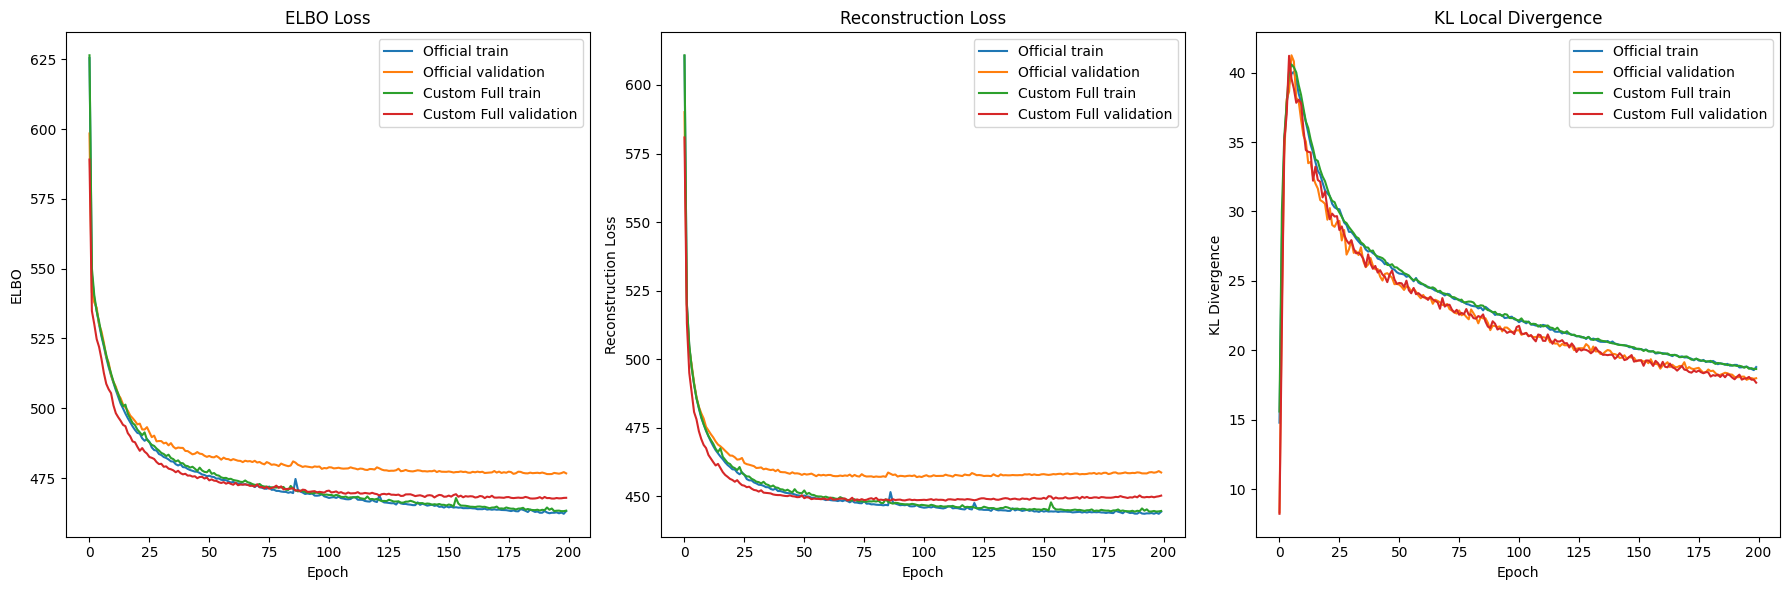

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Plot ELBO Loss
plot_metric(official_hist, "elbo_train", "elbo_validation", "ELBO Loss", "ELBO", ax=axes[0], model_name="Official")
# plot_metric(custom_hist, "elbo_train", "elbo_validation", "ELBO Loss", "ELBO", ax=axes[0], model_name="Custom")
plot_metric(custom_full_hist, "elbo_train", "elbo_validation", "ELBO Loss", "ELBO", ax=axes[0], model_name="Custom Full")
axes[0].legend()

# Plot Reconstruction Loss
plot_metric(official_hist, "reconstruction_loss_train", "reconstruction_loss_validation", "Reconstruction Loss", "Reconstruction Loss", ax=axes[1], model_name="Official")
# plot_metric(custom_hist, "reconstruction_loss_train", "reconstruction_loss_validation", "Reconstruction Loss", "Reconstruction Loss", ax=axes[1], model_name="Custom")
plot_metric(custom_full_hist, "reconstruction_loss_train", "reconstruction_loss_validation", "Reconstruction Loss", "Reconstruction Loss", ax=axes[1], model_name="Custom Full")
axes[1].legend()

# Plot KL Local Divergence
plot_metric(official_hist, "kl_local_train", "kl_local_validation", "KL Local Divergence", "KL Divergence", ax=axes[2], model_name="Official")
# plot_metric(custom_hist, "kl_local_train", "kl_local_validation", "KL Local Divergence", "KL Divergence", ax=axes[2], model_name="Custom")
plot_metric(custom_full_hist, "kl_local_train", "kl_local_validation", "KL Local Divergence", "KL Divergence", ax=axes[2], model_name="Custom Full")
axes[2].legend()

plt.tight_layout()
plt.show()

There is a discrepancy between validation loss metrics for the models, but there doesn't seem to be in training. Why?

# Summary

- Deeper understanding of scVI class definition and structure
- `FullBaselineSCVI` with methods: `setup_anndata`, `get_latent_representation`, and `train`
- `VAEModule` that actually connects to `DecoderSCVI, Encoder` from `scvi.nn`
- Some differences in ELBO and px_rate, that are from the validation process. Requires further investigation.
- The neural networks don't need to be touched, just the I/O and the methods
- Two-step approach: first implement uncoded dSCVI, and then coded dSCVI